In [1]:
   from google.colab import files

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [3]:
# Define hyperparameters
EPOCHS = 100
BATCH_SIZE = 64

In [4]:
# Helper function to load data per window size

def load_window_data(window_size):
    X_train = np.load(f'X_train_w{window_size}.npy')
    y_train = np.load(f'y_train_w{window_size}.npy')
    X_val   = np.load(f'X_val_w{window_size}.npy')
    y_val   = np.load(f'y_val_w{window_size}.npy')
    return X_train, y_train, X_val, y_val

In [5]:
# Train window=24 (test run first)

window_size = 24
X_train, y_train, X_val, y_val = load_window_data(window_size)
model = keras.models.load_model(f'lstm_model_w{window_size}_untrained.keras')

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint(f'best_lstm_w{window_size}.keras', monitor='val_loss', save_best_only=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 18 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


759/759 ━━━━━━━━━━━━━━━━━━━━ 25s 30ms/step - loss: 0.4679 - mae: 0.4710 - val_loss: 0.2781 - val_mae: 0.3362 - learning_rate: 0.0010
Epoch 2/100
759/759 ━━━━━━━━━━━━━━━━━━━━ 40s 28ms/step - loss: 0.4265 - mae: 0.4325 - val_loss: 0.2593 - val_mae: 0.3227 - learning_rate: 0.0010
Epoch 3/100
759/759 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - loss: 0.4116 - mae: 0.4183 - val_loss: 0.2625 - val_mae: 0.3099 - learning_rate: 0.0010
Epoch 4/100
759/759 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 0.4042 - mae: 0.4106 - val_loss: 0.2596 - val_mae: 0.3176 - learning_rate: 0.0010
Epoch 5/100
759/759 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 0.4000 - mae: 0.4064 - val_loss: 0.2547 - val_mae: 0.3103 - learning_rate: 0.0010
Epoch 6/100
759/759 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - loss: 0.3934 - mae: 0.4008 - val_loss: 0.2626 - val_mae: 0.3138 - learning_rate: 0.0010
Epoch 7/100
759/759 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - loss: 0.3890 - mae: 0.3972 - val_loss: 0.2615 - val_mae: 0.3142 - learning_rate: 0.00

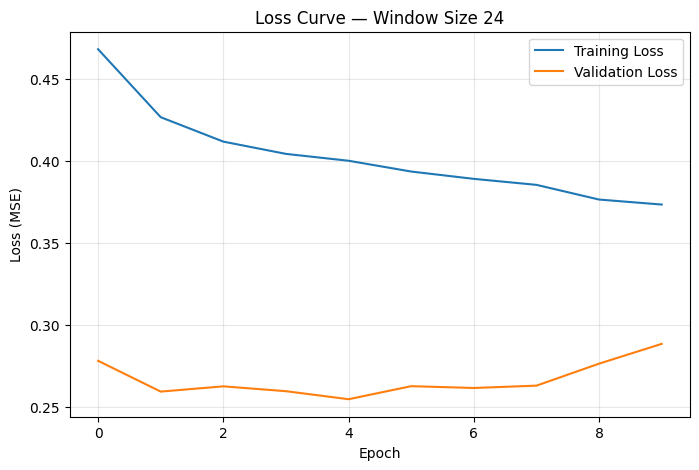

In [6]:
# Plot loss curve function + plot it
def plot_loss_curve(history, window_size):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Loss Curve — Window Size {window_size}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(f'loss_curve_w{window_size}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_loss_curve(history, window_size)


=== Training window size 32 ===
Epoch 1/100
737/737 ━━━━━━━━━━━━━━━━━━━━ 33s 41ms/step - loss: 0.4819 - mae: 0.4813 - val_loss: 0.2918 - val_mae: 0.3403 - learning_rate: 0.0010
Epoch 2/100
737/737 ━━━━━━━━━━━━━━━━━━━━ 43s 44ms/step - loss: 0.4344 - mae: 0.4383 - val_loss: 0.2636 - val_mae: 0.3256 - learning_rate: 0.0010
Epoch 3/100
737/737 ━━━━━━━━━━━━━━━━━━━━ 29s 39ms/step - loss: 0.4177 - mae: 0.4229 - val_loss: 0.2655 - val_mae: 0.3235 - learning_rate: 0.0010
Epoch 4/100
737/737 ━━━━━━━━━━━━━━━━━━━━ 29s 39ms/step - loss: 0.4111 - mae: 0.4157 - val_loss: 0.2605 - val_mae: 0.3219 - learning_rate: 0.0010
Epoch 5/100
737/737 ━━━━━━━━━━━━━━━━━━━━ 29s 39ms/step - loss: 0.4046 - mae: 0.4097 - val_loss: 0.2743 - val_mae: 0.3296 - learning_rate: 0.0010
Epoch 6/100
737/737 ━━━━━━━━━━━━━━━━━━━━ 42s 41ms/step - loss: 0.4026 - mae: 0.4073 - val_loss: 0.2655 - val_mae: 0.3072 - learning_rate: 0.0010
Epoch 7/100
737/737 ━━━━━━━━━━━━━━━━━━━━ 30s 40ms/step - loss: 0.3972 - mae: 0.4021 - val_loss: 0

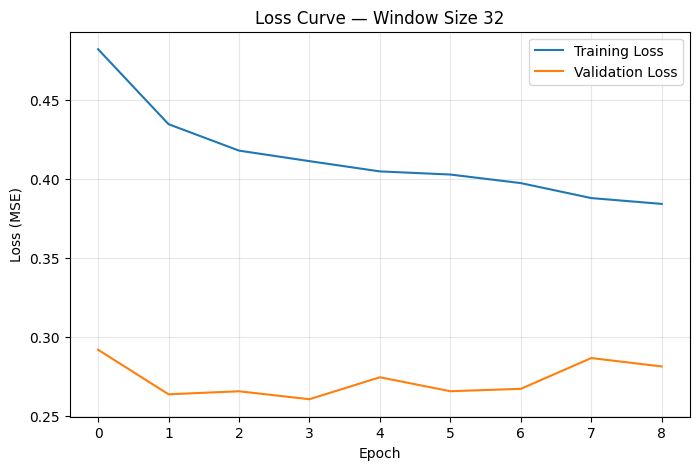


=== Training window size 48 ===
Epoch 1/100
677/677 ━━━━━━━━━━━━━━━━━━━━ 44s 60ms/step - loss: 0.5013 - mae: 0.4940 - val_loss: 0.2889 - val_mae: 0.3543 - learning_rate: 0.0010
Epoch 2/100
677/677 ━━━━━━━━━━━━━━━━━━━━ 39s 58ms/step - loss: 0.4541 - mae: 0.4514 - val_loss: 0.2663 - val_mae: 0.3290 - learning_rate: 0.0010
Epoch 3/100
677/677 ━━━━━━━━━━━━━━━━━━━━ 39s 57ms/step - loss: 0.4333 - mae: 0.4349 - val_loss: 0.2639 - val_mae: 0.3155 - learning_rate: 0.0010
Epoch 4/100
677/677 ━━━━━━━━━━━━━━━━━━━━ 37s 55ms/step - loss: 0.4260 - mae: 0.4270 - val_loss: 0.2665 - val_mae: 0.3133 - learning_rate: 0.0010
Epoch 5/100
677/677 ━━━━━━━━━━━━━━━━━━━━ 38s 56ms/step - loss: 0.4270 - mae: 0.4250 - val_loss: 0.2553 - val_mae: 0.3179 - learning_rate: 0.0010
Epoch 6/100
677/677 ━━━━━━━━━━━━━━━━━━━━ 42s 58ms/step - loss: 0.4162 - mae: 0.4175 - val_loss: 0.2631 - val_mae: 0.3137 - learning_rate: 0.0010
Epoch 7/100
677/677 ━━━━━━━━━━━━━━━━━━━━ 38s 56ms/step - loss: 0.4099 - mae: 0.4117 - val_loss: 0

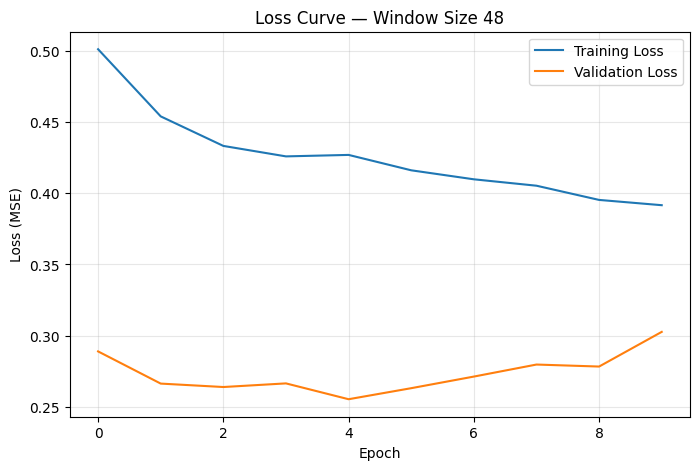

In [7]:
# Train window=32 and window=48, storing all results
results = {24: {'history': history, 'best_val_loss': min(history.history['val_loss'])}}

for window_size in [32, 48]:
    X_train, y_train, X_val, y_val = load_window_data(window_size)
    model = keras.models.load_model(f'lstm_model_w{window_size}_untrained.keras')

    callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        keras.callbacks.ModelCheckpoint(f'best_lstm_w{window_size}.keras', monitor='val_loss', save_best_only=True),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
    ]

    print(f"\n=== Training window size {window_size} ===")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )

    plot_loss_curve(history, window_size)
    results[window_size] = {'history': history, 'best_val_loss': min(history.history['val_loss'])}

In [8]:
# Compare all 3 and pick the best window size
print("=== Final Comparison ===")
for w, r in results.items():
    print(f"Window size {w}: best validation loss (MSE) = {r['best_val_loss']:.5f}")

best_window = min(results, key=lambda w: results[w]['best_val_loss'])
print(f"\nBest performing window size: {best_window}")

=== Final Comparison ===
Window size 24: best validation loss (MSE) = 0.25469
Window size 32: best validation loss (MSE) = 0.26046
Window size 48: best validation loss (MSE) = 0.25534

Best performing window size: 24


In [9]:
# Download everything
for window_size in [24, 32, 48]:
    files.download(f'best_lstm_w{window_size}.keras')
    files.download(f'loss_curve_w{window_size}.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>